In [1]:
import pandas as pd
import numpy as np

In [2]:
# Loading all the datasets
train_df = pd.read_csv("./helmet_detection_train.csv")
test_df = pd.read_csv("./helmet_detection_test.csv")
val_df = pd.read_csv("./helmet_detection_validation.csv")

classes_df = pd.read_csv("./36_class.csv", names=['class', 'label'])
data_split_df = pd.read_csv("./data_split.csv")

In [3]:
data_split_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910 entries, 0 to 909
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   video_id  910 non-null    object
 1   Set       910 non-null    object
dtypes: object(2)
memory usage: 14.3+ KB


In [4]:
data_split_df["Set"].unique()

array(['validation', 'test', 'training'], dtype=object)

In [5]:
# Number of unique highways in each splits
unique_highways_train = len(data_split_df[data_split_df["Set"] == "training" ])
unique_highways_test = len(data_split_df[data_split_df["Set"] == "test" ])
unique_highways_validation = len(data_split_df[data_split_df["Set"] == "validation" ])

print(f"Unique highways in train set: {unique_highways_train}")
print(f"Unique highways in test set: {unique_highways_test}")
print(f"Unique highways in val set: {unique_highways_validation}")

Unique highways in train set: 636
Unique highways in test set: 182
Unique highways in val set: 92


In [6]:
classes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   36 non-null     object
 1   label   36 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 708.0+ bytes


In [7]:
# Number of classes in the dataset
print(f"No. of classes in the dataset: {len(classes_df)}")
print(f"They are\n {"="*50}")
print(classes_df["class"])

No. of classes in the dataset: 36
They are
0                                   DNoHelmetP1NoHelmet
1                                       DHelmetP1Helmet
2                                               DHelmet
3                                             DNoHelmet
4                                     DHelmetP1NoHelmet
5                           DHelmetP0NoHelmetP1NoHelmet
6                           DHelmetP1NoHelmetP2NoHelmet
7                         DNoHelmetP1NoHelmetP2NoHelmet
8                             DHelmetP1NoHelmetP2Helmet
9                                     DNoHelmetP1Helmet
10                  DHelmetP0NoHelmetP1NoHelmetP2Helmet
11                        DNoHelmetP0NoHelmetP1NoHelmet
12                                  DNoHelmetP0NoHelmet
13                                    DHelmetP0NoHelmet
14                            DNoHelmetP1HelmetP2Helmet
15                              DHelmetP1HelmetP2Helmet
16              DNoHelmetP0NoHelmetP1NoHelmetP2NoHelmet
17   

## Reducing to just pillion and rider

In [8]:
def reduce_pillion(text: str):
    if "P" not in text:
        return text

    driver_helmet_status = text.split("P")[0]
    driver_stripped_text = text.lstrip(driver_helmet_status)

    if "NoHelmet" in driver_stripped_text:
        return driver_helmet_status+"PNoHelmet"
    else:
        return driver_helmet_status+"PHelmet"

reduced_classes_df = classes_df.copy()

reduced_classes_df["class"] = reduced_classes_df["class"].apply(reduce_pillion)
        

In [9]:
print(reduced_classes_df["class"].unique())

['DNoHelmetPNoHelmet' 'DHelmetPHelmet' 'DHelmet' 'DNoHelmet'
 'DHelmetPNoHelmet' 'DNoHelmetPHelmet']


In [10]:
train_df.head()

,image_name,label,track_id,x1,y1,x2,y2
0,Bago_highway_11_01,DNoHelmet,_msurfy1df,1481,605,1549,714
1,Bago_highway_11_02,DNoHelmet,_msurfy1df,1475,605,1543,714
2,Bago_highway_11_03,DNoHelmet,_msurfy1df,1469,605,1536,714
3,Bago_highway_11_04,DNoHelmet,_msurfy1df,1463,605,1530,715
4,Bago_highway_11_05,DNoHelmet,_msurfy1df,1457,605,1524,715


In [11]:
len(train_df)

199603

In [12]:
## Train distribution of labels
train_df["label"].value_counts()

label
DHelmet                                              79852
DHelmetP1Helmet                                      40135
DNoHelmet                                            34568
DNoHelmetP1NoHelmet                                  19349
DHelmetP1NoHelmet                                     8921
DNoHelmetP1NoHelmetP2NoHelmet                         4790
DNoHelmetP1Helmet                                     2500
DHelmetP1NoHelmetP2Helmet                             1844
DHelmetP1NoHelmetP2NoHelmet                           1534
DNoHelmetP0NoHelmetP1NoHelmet                          979
DNoHelmetP0NoHelmet                                    579
DHelmetP0NoHelmetP1NoHelmet                            549
DHelmetP0NoHelmetP1Helmet                              542
DHelmetP0NoHelmet                                      531
DNoHelmetP0NoHelmetP1NoHelmetP2NoHelmet                436
DHelmetP1HelmetP2Helmet                                435
DHelmetP0HelmetP1Helmet                           

In [13]:
# Train distribution, with reduction transformation
train_reduced = train_df.copy()
train_reduced["label"] = train_reduced["label"].apply(reduce_pillion)

train_label_counts = train_reduced["label"].value_counts()
print(train_label_counts)

label
DHelmet               79852
DHelmetPHelmet        41255
DNoHelmet             34568
DNoHelmetPNoHelmet    26557
DHelmetPNoHelmet      14794
DNoHelmetPHelmet       2577
Name: count, dtype: int64


In [14]:
train_label_counts.sum()

np.int64(199603)

In [15]:
len(train_reduced["label"])

199603

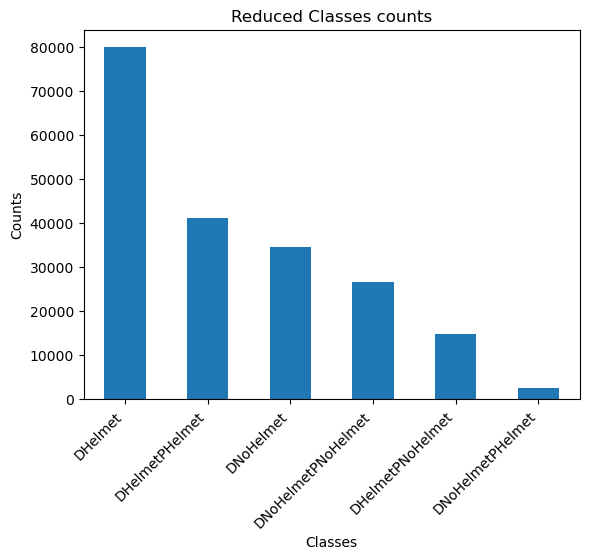

In [16]:
import matplotlib.pyplot as plt

train_label_counts.plot(kind='bar')

plt.xlabel("Classes")
plt.ylabel("Counts")
plt.xticks(rotation=45, ha='right')
plt.title("Reduced Classes counts")

plt.show()

## Distribution across sets after transformation

In [17]:
test_reduced = test_df.copy()
test_reduced["label"] = test_reduced["label"].apply(reduce_pillion)

val_reduced = val_df.copy()
val_reduced["label"] = val_reduced["label"].apply(reduce_pillion)

# Normalized counts 
train_normalized_counts = train_reduced["label"].value_counts(normalize=True)
test_normalized_counts = test_reduced["label"].value_counts(normalize=True)
val_normalized_counts = val_reduced["label"].value_counts(normalize=True)

comparison_df = pd.DataFrame({
    'Train': train_normalized_counts,
    'Validation': val_normalized_counts,
    'Test': test_normalized_counts
})

comparison_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, DHelmet to DNoHelmetPHelmet
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Train       6 non-null      float64
 1   Validation  6 non-null      float64
 2   Test        6 non-null      float64
dtypes: float64(3)
memory usage: 192.0+ bytes


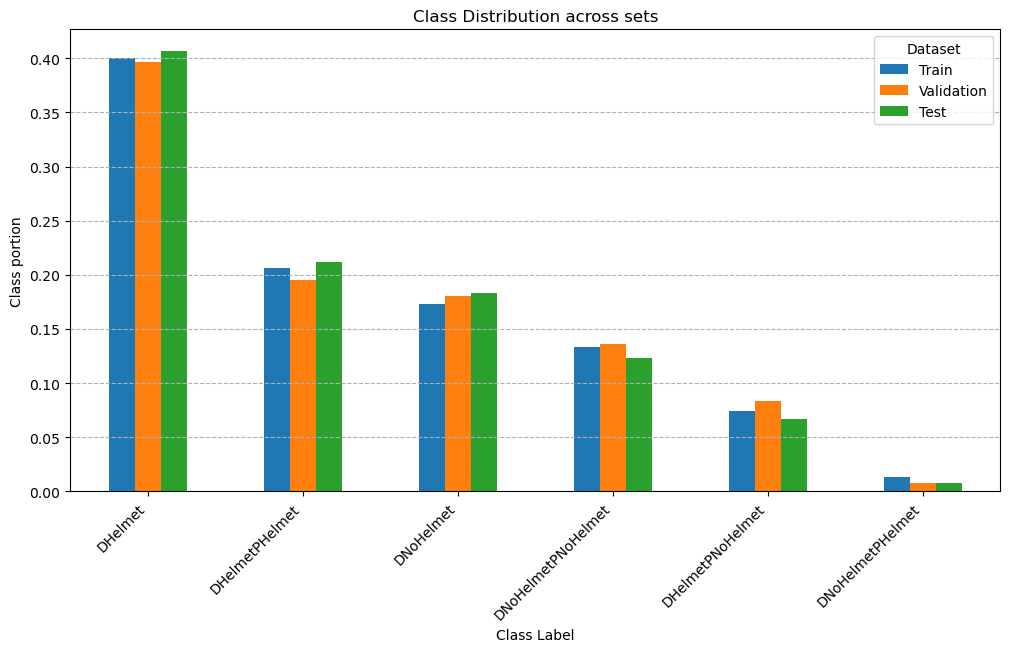

In [18]:
comparison_df.plot(kind='bar', figsize=(12, 6))

plt.title('Class Distribution across sets')
plt.ylabel('Class portion')
plt.xlabel('Class Label')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.legend(title="Dataset")

plt.show()

## Classes of violation vs no violation

In [19]:
def reduce_to_violation(text: str):
    if "NoHelmet" in text:
        return "Violation"
    else:
        return "NoViolation"

train_violation_classes = train_df.copy()
train_violation_classes['label'] = train_violation_classes['label'].apply(reduce_to_violation)

val_violation_classes = val_df.copy()
val_violation_classes['label'] = val_violation_classes['label'].apply(reduce_to_violation)

test_violation_classes = test_df.copy()
test_violation_classes['label'] = test_violation_classes['label'].apply(reduce_to_violation)



In [20]:
train_violation_df_counts = train_violation_classes["label"].value_counts()
print(train_violation_df_counts)

label
NoViolation    121107
Violation       78496
Name: count, dtype: int64


In [21]:
# Normalized counts 
train_normalized_counts2 = train_violation_classes["label"].value_counts(normalize=True)
test_normalized_counts2 = test_violation_classes["label"].value_counts(normalize=True)
val_normalized_counts2 = val_violation_classes["label"].value_counts(normalize=True)

comparison_df2 = pd.DataFrame({
    'Train': train_normalized_counts2,
    'Validation': val_normalized_counts2,
    'Test': test_normalized_counts2
})

comparison_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, NoViolation to Violation
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Train       2 non-null      float64
 1   Validation  2 non-null      float64
 2   Test        2 non-null      float64
dtypes: float64(3)
memory usage: 64.0+ bytes


In [22]:
comparison_df2.head()

,Train,Validation,Test
label,,,
NoViolation,0.606739,0.591964,0.618277
Violation,0.393261,0.408036,0.381723


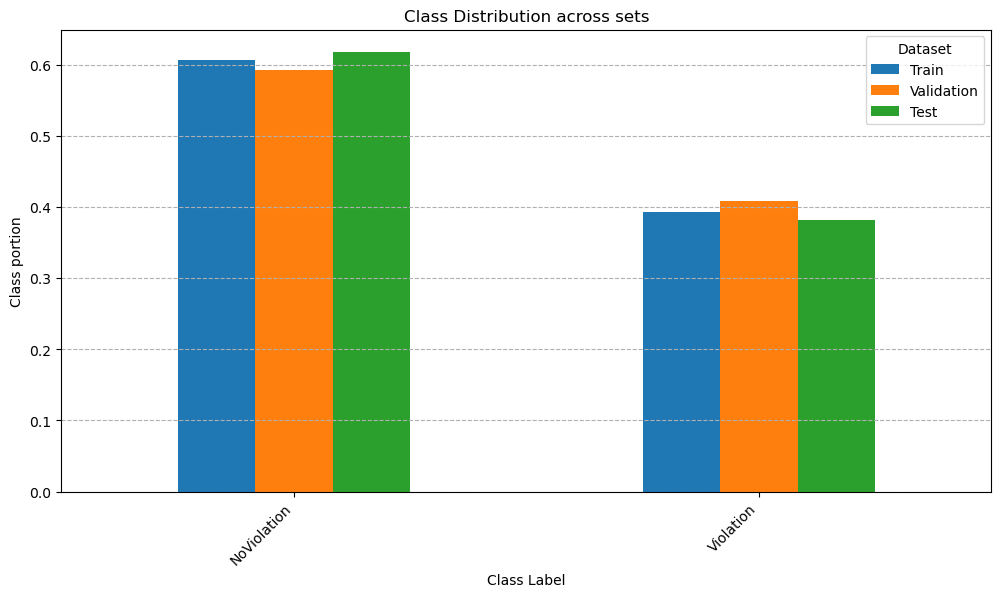

In [23]:
comparison_df2.plot(kind='bar', figsize=(12, 6))

plt.title('Class Distribution across sets')
plt.ylabel('Class portion')
plt.xlabel('Class Label')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.legend(title="Dataset")

plt.show()

In [24]:
len(train_violation_classes[train_violation_classes["track_id"] == "_msurfy1df"])

25

In [25]:
train_violation_classes.columns


Index(['image_name', 'label', 'track_id', 'x1', 'y1', 'x2', 'y2'], dtype='object')

In [26]:
train_violation_classes["image_only"] = train_violation_classes["image_name"]
print(train_violation_classes.head())

           image_name      label    track_id    x1   y1    x2   y2  \
0  Bago_highway_11_01  Violation  _msurfy1df  1481  605  1549  714   
1  Bago_highway_11_02  Violation  _msurfy1df  1475  605  1543  714   
2  Bago_highway_11_03  Violation  _msurfy1df  1469  605  1536  714   
3  Bago_highway_11_04  Violation  _msurfy1df  1463  605  1530  715   
4  Bago_highway_11_05  Violation  _msurfy1df  1457  605  1524  715   

           image_only  
0  Bago_highway_11_01  
1  Bago_highway_11_02  
2  Bago_highway_11_03  
3  Bago_highway_11_04  
4  Bago_highway_11_05  


In [27]:
print(train_violation_classes[train_violation_classes["image_name"].isin(["Bago_highway_11_16","Bago_highway_11_17"] )])

            image_name        label    track_id    x1   y1    x2   y2  \
16  Bago_highway_11_16  NoViolation  _kj96uh9tz   943  626  1050  796   
17  Bago_highway_11_16    Violation  _msurfy1df  1388  596  1453  706   
18  Bago_highway_11_17  NoViolation  _kj96uh9tz   946  627  1051  798   
19  Bago_highway_11_17    Violation  _msurfy1df  1382  595  1448  704   

            image_only  
16  Bago_highway_11_16  
17  Bago_highway_11_16  
18  Bago_highway_11_17  
19  Bago_highway_11_17  


In [28]:
train_violation_classes["image_only"] = train_violation_classes["image_only"].apply(lambda image: "_".join(image.split("_")[:-1]))
print(train_violation_classes[train_violation_classes["image_name"].isin(["Bago_highway_11_16"] )])

            image_name        label    track_id    x1   y1    x2   y2  \
16  Bago_highway_11_16  NoViolation  _kj96uh9tz   943  626  1050  796   
17  Bago_highway_11_16    Violation  _msurfy1df  1388  596  1453  706   

         image_only  
16  Bago_highway_11  
17  Bago_highway_11  


### Removing redundant images from train

In [29]:
def remove_redundant_images(df):
    '''
    Removes redundant images. Make sure "image_only" column exists in df (not present in original df), 
    which should be the highway key without the image number.
    
    Args:
        df: Any train, test, val df to remove the redundant images, thus alleviating training constraints

    Returns:
        df: The df without redundant images returned
    '''
    df_columns = df.columns
    
    # Check for required columns 
    df_required_columns = ['image_name', 'label', 'track_id', 'x1', 'x2', 'y1', 'y2', 'image_only']
    required_columns_missing = any(required_column not in df_columns for required_column in df_required_columns)

    if required_columns_missing:
        raise KeyError("Missing required columns from df. They are 'image_name', 'label', 'track_id', 'x1', 'x2', 'y1', 'y2', 'image_only'")
    
    # label + track_id signature
    df['obj_signature'] = (
        df['label'].astype(str) + ":" + 
        df['track_id'].astype(str)
    )
    
    # A unique scene_signature for every image name
    # Sorting is crucial so that [A:Violation, B:NoViolation] matches [B:NoViolation, A:Violation]
    scene_signatures = df.groupby('image_name')['obj_signature'].apply(
        lambda x: "|".join(sorted(x))
    ).reset_index()
    
    # Bringing back the 'image_only' context for deduplication
    scene_signatures = scene_signatures.merge(
        df[['image_name', 'image_only']].drop_duplicates(),
        on='image_name'
    )
    
    # 4. Droping duplicates on the Scene Signature and the highway (image_only)
    # This keeps the first image that showed this specific configuration of objects/labels
    unique_image_names = scene_signatures.drop_duplicates(
        subset=['image_only', 'obj_signature'], 
        keep='first'
    )['image_name']
    
    # Filter original dataframe using unique image names
    df_train_final = df[df['image_name'].isin(unique_image_names)].copy()
    
    # Removing the helper column from the final result
    df_train_final.drop(columns=['obj_signature'], inplace=True)

    return df_train_final

In [30]:
train_violation_classes

,image_name,label,track_id,x1,y1,x2,y2,image_only
0,Bago_highway_11_01,Violation,_msurfy1df,1481,605,1549,714,Bago_highway_11
1,Bago_highway_11_02,Violation,_msurfy1df,1475,605,1543,714,Bago_highway_11
2,Bago_highway_11_03,Violation,_msurfy1df,1469,605,1536,714,Bago_highway_11
3,Bago_highway_11_04,Violation,_msurfy1df,1463,605,1530,715,Bago_highway_11
4,Bago_highway_11_05,Violation,_msurfy1df,1457,605,1524,715,Bago_highway_11
...,...,...,...,...,...,...,...,...
199598,Yangon_II_8_98,Violation,_x9goz84nx,1265,652,1414,872,Yangon_II_8
199599,Yangon_II_8_98,NoViolation,_ryfhoyluy,1073,642,1141,741,Yangon_II_8
199600,Yangon_II_8_99,Violation,_y1daj9j3r,380,686,520,947,Yangon_II_8
199601,Yangon_II_8_99,Violation,_x9goz84nx,1240,654,1385,869,Yangon_II_8


In [31]:
df_train_final = remove_redundant_images(train_violation_classes)

In [53]:
# Count of images before deduplication
len(train_df["image_name"].unique())

56915

In [32]:
# Checking count of images
len(df_train_final["image_name"].unique())

9785

In [55]:
# Also checking the count of highways in both sets
train_df["image_only"] = train_df["image_name"]
train_df["image_only"] = train_df["image_only"].apply(lambda x: "_".join(x.split('_')[:-1]))

print(f"Highways count in original train set {len(train_df["image_only"].unique())}")
print(f"Highways count in deduplicated train set {len(df_train_final["image_only"].unique())}")

Highways count in original train set 636
Highways count in deduplicated train set 636


Looks Good, our deduplication procedure was correct

In [33]:
# Checking label differentiation
df_train_final["label"].value_counts()

label
NoViolation    29171
Violation      14857
Name: count, dtype: int64

### Similarly, removing from Val

In [34]:
val_violation_classes["image_name"] = val_violation_classes["image_id"]
val_violation_classes.drop('image_id', axis=1, inplace=True)

In [35]:
val_violation_classes["image_only"] = val_violation_classes["image_name"]
val_violation_classes["image_only"] = val_violation_classes["image_only"].apply(lambda image: "_".join(image.split("_")[:-1]))
df_val_final = remove_redundant_images(val_violation_classes)

In [36]:
# Checking count of images
len(df_val_final["image_name"].unique())

1357

In [37]:
# Checking label differentiation
df_val_final["label"].value_counts()

label
NoViolation    4345
Violation      2044
Name: count, dtype: int64

### Similarily, removing from test

In [38]:
test_violation_classes["image_only"] = test_violation_classes["image_name"]
test_violation_classes["image_only"] = test_violation_classes["image_only"].apply(lambda image: "_".join(image.split("_")[:-1]))
df_test_final = remove_redundant_images(test_violation_classes)

In [39]:
# Checking count of images
len(df_test_final["image_name"].unique())

2406

In [40]:
# Checking label differentiation
df_test_final["label"].value_counts()

label
NoViolation    6746
Violation      3332
Name: count, dtype: int64

### Final distribution

In [42]:
# Normalized counts 
train_deduplicated = df_train_final["label"].value_counts()
test_deduplicated = df_test_final["label"].value_counts()
val_deduplicated = df_val_final["label"].value_counts()

final_comparision_df = pd.DataFrame({
    'Train': train_deduplicated,
    'Validation': val_deduplicated,
    'Test': test_deduplicated
})

final_comparision_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, NoViolation to Violation
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Train       2 non-null      int64
 1   Validation  2 non-null      int64
 2   Test        2 non-null      int64
dtypes: int64(3)
memory usage: 64.0+ bytes


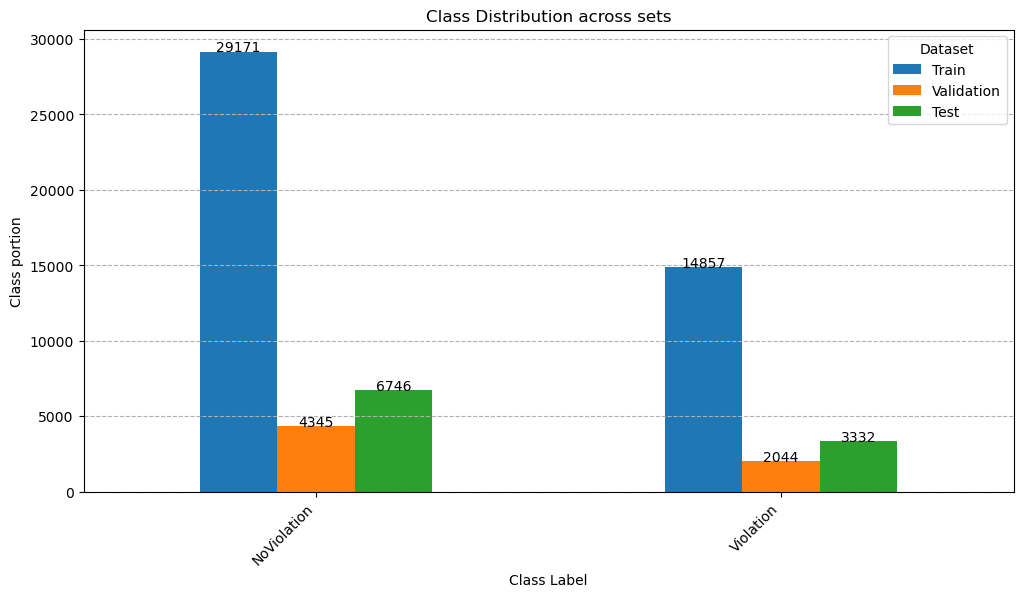

In [43]:
ax = final_comparision_df.plot(kind='bar', figsize=(12, 6))

plt.title('Class Distribution across sets')
plt.ylabel('Class portion')
plt.xlabel('Class Label')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height(), '{:d}'.format(int(p.get_height())), ha='center')
    
plt.legend(title="Dataset")

plt.show()

### Images count in deduplicated df

In [50]:
df_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44028 entries, 0 to 199439
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_name  44028 non-null  object
 1   label       44028 non-null  object
 2   track_id    44028 non-null  object
 3   x1          44028 non-null  int64 
 4   y1          44028 non-null  int64 
 5   x2          44028 non-null  int64 
 6   y2          44028 non-null  int64 
 7   image_only  44028 non-null  object
dtypes: int64(4), object(4)
memory usage: 3.0+ MB


In [49]:
df_train_final["label"].value_counts()

label
NoViolation    29171
Violation      14857
Name: count, dtype: int64

In [48]:
# Images counts 
train_deduplicated_images = len(df_train_final["image_name"].unique())
test_deduplicated_images = len(df_test_final["image_name"].unique())
val_deduplicated_images = len(df_val_final["image_name"].unique())


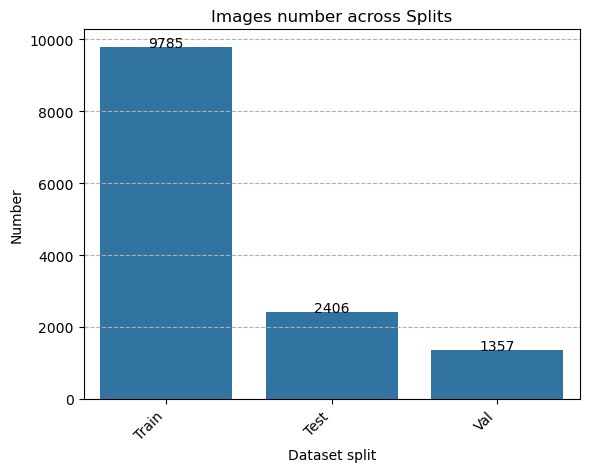

In [52]:
import seaborn as sns

images_labels = ['Train', 'Test', 'Val']
images_counts_per_split = [train_deduplicated_images, test_deduplicated_images, val_deduplicated_images]

ax_images = sns.barplot(x=images_labels, y=images_counts_per_split)

plt.title('Images number across Splits')
plt.ylabel('Number')
plt.xlabel('Dataset split')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')

for p in ax_images.patches:
    ax_images.text(p.get_x() + p.get_width() / 2, p.get_height(), '{:d}'.format(int(p.get_height())), ha='center')

plt.show()